# Brain Tumor Segmentation using SwinUNETR

## Project Overview
This notebook implements a deep learning pipeline to segment brain tumors from MRI scans using the BraTS dataset. We utilize a SwinUNETR architecture to predict segmentation masks from multi-modal MRI inputs.

## Objectives
1.  **Data Loading**: Load 3D MRI volumes (NIfTI format).
2.  **Preprocessing**: Normalize and format data for the model.
3.  **Model**: Implement a SwinUNETR architecture in PyTorch.
4.  **Training**: Train the model using Dice Loss.
5.  **Visualization**: Visualize inputs, ground truth, and predictions.


## 1. Setup and Imports
Install necessary packages if not already present.


In [6]:
!pip install monai nibabel matplotlib torch torchvision tqdm scikit-learn comet_ml -q

In [7]:
import comet_ml
from comet_ml import Experiment
import os
import glob
import gc
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

from monai import transforms
from monai import data
from monai.networks.nets import SwinUNETR
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.data import decollate_batch
from monai.transforms import AsDiscrete, Compose, Activations

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f"Using device: {device}")



Using device: cpu


## 2. Data Configuration

In [9]:
# Initialize Comet ML Experiment
experiment = Experiment(
    api_key = "VDWJEDjieOQbqDskMAw7Cr1av",
    project_name="brain-tumor-segmentation",
    auto_metric_logging=True,
    auto_param_logging=True,
    auto_histogram_weight_logging=True,
    auto_histogram_gradient_logging=True,
    auto_histogram_activation_logging=True,
)

DATASET_ROOT = "/kaggle/input/brain-tumor-segmentation-hackathon"

# Parameters
IMG_SIZE = 128
BATCH_SIZE = 1
LEARNING_RATE = 1e-4
NUM_EPOCHS = 100
VALIDATION_SPLIT = 0.2

# Log parameters
parameters = {
    "IMG_SIZE":IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "epochs": NUM_EPOCHS,
    "validation_split": VALIDATION_SPLIT,
}
experiment.log_parameters(parameters)

test_index = 0      # Index for visualization

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : logical_hearse_2918
COMET INFO:     url                   : https://www.comet.com/mhmd7syn/brain-tumor-segmentation/2b088b4009ff48648bc9b96a2ae01420
COMET INFO:   Parameters:
COMET INFO:     IMG_SIZE         : 128
COMET INFO:     batch_size       : 1
COMET INFO:     epochs           : 100
COMET INFO:     learning_rate    : 0.0001
COMET INFO:     validation_split : 0.2
COMET INFO:   Uploads:
COMET INFO:     environment details : 1
COMET INFO:     filename            : 1
COMET INFO:     installed packages  : 1
COMET INFO:     notebook            : 1
COMET INFO:     os packages         : 1
COMET INFO:     source_code         : 1
COMET INFO: 
COMET WARNI

## 4. Data Visualization
Let's visualize a sample from the dataset to understand the modalities and labels.
- **Modalities**: FLAIR, T1, T1ce, T2
- **Labels**: Necrotic (NCR), Edema (ED), Enhancing Tumor (ET)

In [4]:
from matplotlib import animation, rc
rc('animation', html='jshtml')


def create_animation(ims):
    fig = plt.figure(figsize=(6, 6))
    plt.axis('off')
    im = plt.imshow(ims[0], cmap="gray")

    def animate_func(i):
        im.set_array(ims[i])
        return [im]

    return animation.FuncAnimation(fig, animate_func, frames = len(ims), interval = 1000//24)


In [20]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc

rc('animation', html='jshtml')

def create_nifti_animation(file_path):
    # Load and convert to numpy array
    img_proxy = nib.load(file_path)
    data = img_proxy.get_fdata()
    
    # --- FIX 1: Normalize intensity ---
    # This ensures the brightest pixel is 1 and darkest is 0
    if np.max(data) > np.min(data):
        data = (data - np.min(data)) / (np.max(data) - np.min(data))
    
    # --- FIX 2: Reorient ---
    # BraTS data is often (H, W, Slices). We want to animate the 3rd axis.
    # If the image looks sideways, you can use np.transpose or np.rot90
    num_slices = data.shape[2]

    fig = plt.figure(figsize=(6, 6))
    plt.axis('off')
    
    # Initialize with a middle slice to ensure we see something immediately
    middle_slice = num_slices // 2
    im = plt.imshow(data[:, :, middle_slice], cmap="gray")

    def animate_func(i):
        im.set_array(data[:, :, i])
        return [im]

    anim = animation.FuncAnimation(
        fig, 
        animate_func, 
        frames=num_slices, 
        interval=50, # Slightly faster playback
        blit=True
    )
    
    plt.close()
    return anim

file_path = '/kaggle/input/instant-odc-ai-hackathon/Train/BraTS2021_00002/BraTS2021_00002_flair.nii/00000014_brain_flair.nii'
create_nifti_animation(file_path)

In [ ]:
rc('animation', html='jshtml')

def create_nifti_animation_sideways(file_path):
    # Load and convert to numpy array
    img_proxy = nib.load(file_path)
    data = img_proxy.get_fdata()
    
    # --- FIX 1: Normalize intensity ---
    # This ensures the brightest pixel is 1 and darkest is 0
    if np.max(data) > np.min(data):
        data = (data - np.min(data)) / (np.max(data) - np.min(data))
    
    # --- FIX 2: Reorient ---
    # BraTS data is often (H, W, Slices). We want to animate the 3rd axis.
    # If the image looks sideways, you can use np.transpose or np.rot90
    num_slices = data.shape[0]

    fig = plt.figure(figsize=(6, 6))
    plt.axis('off')
    
    # Initialize with a middle slice to ensure we see something immediately
    middle_slice = num_slices // 2
    im = plt.imshow(data[middle_slice, :, :], cmap="gray")

    def animate_func(i):
        im.set_array(data[i, :, :])
        return [im]

    anim = animation.FuncAnimation(
        fig, 
        animate_func, 
        frames=num_slices, 
        interval=50, # Slightly faster playback
        blit=True
    )
    
    plt.close()
    return anim

create_nifti_animation_sideways(file_path)

In [10]:
import nibabel as nib
import os
import albumentations as A
import numpy as np


class ImageReader:
    def __init__(self, root:str, img_size:int=256, normalize:bool=False, single_class:bool=False):
        pad_size = 256 if img_size > 256 else 224
        self.resize = A.Compose(
            [
                A.PadIfNeeded(min_height=pad_size, min_width=pad_size, value=0),
                A.Resize(img_size, img_size)
            ]
        )
        self.normalize=normalize
        self.single_class=single_class
        self.root=root
        
    def load_patient_scan(self, idx:int,scan_type:str='flair') -> dict:
        img_path = self.read_file(idx,scan_type)
        seg_path = self.read_file(idx,'seg')
        raw_image = nib.load(img_path).get_fdata()
        raw_mask = nib.load(seg_path).get_fdata()
        processed_frames, processed_masks = [], []
        for frame_idx in range(raw_image.shape[2]):
            frame = raw_image[:, :, frame_idx]
            mask = raw_mask[:, :, frame_idx]
            if self.normalize:
                if frame.max() > 0:
                    frame = frame/frame.max()
                frame = frame.astype(np.float32)
            else:
                frame = frame.astype(np.uint8)
            resized = self.resize(image=frame, mask=mask)
            processed_frames.append(resized['image'])
            processed_masks.append(1*(resized['mask'] > 0) if self.single_class else resized['mask'])
        return {
            'scan': np.stack(processed_frames, 0),
            'segmentation': np.stack(processed_masks, 0),
            'orig_shape': raw_image.shape
        }
    
    def read_file(self, idx:int, scan_type:str='flair') -> dict:
        patient_id = str(idx).zfill(5)
        scan_dir = f'{self.root}/BraTS2021_{patient_id}/BraTS2021_{patient_id}_{scan_type}.nii'
                # 1. Try to find the file in the specific folder (Nested structure)
        if os.path.isdir(scan_dir):
            files = glob.glob(os.path.join(scan_dir, "*.nii"))
            if files:
                if len(files) > 1:
                    print(f"Multiple files found in {folder_path}: {len(files)}")
                # return files[0]
                return files[0]
        # 2. Fallback: Check if the folder_path itself is actually the file
        if os.path.isfile(scan_dir):
            return scan_dir
      
        raise FileNotFoundError(f"File for modality '{scan_type}' not found in {idx}")

In [12]:
import plotly.graph_objects as go
import numpy as np


def generate_3d_scatter(
    x:np.array, y:np.array, z:np.array, colors:np.array,
    size:int=3, opacity:float=0.2, scale:str='Teal',
    hover:str='skip', name:str='MRI'
) -> go.Scatter3d:
    return go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers', hoverinfo=hover,
        marker = dict(
            size=size, opacity=opacity,
            color=colors, colorscale=scale
        ),
        name=name
    )


class ImageViewer3d():
    def __init__(
        self, reader:ImageReader, mri_downsample:int=10, mri_colorscale:str='Ice'
    ) -> None:
        self.reader = reader
        self.mri_downsample = mri_downsample
        self.mri_colorscale = mri_colorscale

    def load_clean_mri(self, image:np.array, orig_dim:int) -> dict:
        shape_offset = image.shape[1]/orig_dim
        z, x, y = (image > 0).nonzero()
        # only (1/mri_downsample) is sampled for the resulting image
        x, y, z = x[::self.mri_downsample], y[::self.mri_downsample], z[::self.mri_downsample]
        colors = image[z, x, y]
        return dict(x=x/shape_offset, y=y/shape_offset, z=z, colors=colors)
    
    def load_tumor_segmentation(self, image:np.array, orig_dim:int) -> dict:
        tumors = {}
        shape_offset = image.shape[1]/orig_dim
        # 1/1, 1/3 and 1/5 pixels for tumor tissue classes 1(core), 2(invaded) and 4(enhancing)
        sampling = {
            1: 1, 2: 3, 4: 5
        }
        for class_idx in sampling:
            z, x, y = (image == class_idx).nonzero()
            x, y, z = x[::sampling[class_idx]], y[::sampling[class_idx]], z[::sampling[class_idx]]
            tumors[class_idx] = dict(
                x=x/shape_offset, y=y/shape_offset, z=z,
                colors=class_idx/4
            )
        return tumors
    
    def collect_patient_data(self, scan:dict) -> tuple:
        clean_mri = self.load_clean_mri(scan['scan'], scan['orig_shape'][0])
        tumors = self.load_tumor_segmentation(scan['segmentation'], scan['orig_shape'][0])
        markers_created = clean_mri['x'].shape[0] + sum(tumors[class_idx]['x'].shape[0] for class_idx in tumors)
        return [
            generate_3d_scatter(**clean_mri, scale=self.mri_colorscale, opacity=0.3, hover='skip', name='Brain MRI'),
            generate_3d_scatter(**tumors[1], opacity=0.8, hover='all', name='Necrotic tumor core'),
            generate_3d_scatter(**tumors[2], opacity=0.4, hover='all', name='Peritumoral invaded tissue'),
            generate_3d_scatter(**tumors[4], opacity=0.4, hover='all', name='GD-enhancing tumor'),
        ], markers_created
    
    def get_3d_scan(self, patient_idx:int, scan_type:str='flair') -> go.Figure:
        scan = self.reader.load_patient_scan(patient_idx, scan_type)
        data, num_markers = self.collect_patient_data(scan)
        fig = go.Figure(data=data)
        fig.update_layout(
            title=f"[Patient id:{patient_idx}] brain MRI scan ({num_markers} points)",
            legend_title="Pixel class (click to enable/disable)",
            font=dict(
                family="Courier New, monospace",
                size=14,
            ),
            margin=dict(
                l=0,r=0,b=0,t=30
            ),
            legend=dict(itemsizing='constant')
        )
        return fig

In [13]:
reader = ImageReader('/kaggle/input/instant-odc-ai-hackathon/Train', img_size=128, normalize=True, single_class=False)
viewer = ImageViewer3d(reader, mri_downsample=25)

/tmp/ipykernel_55/1740246921.py:12: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=pad_size, min_width=pad_size, value=0),


In [16]:
import plotly
fig = viewer.get_3d_scan(45, 't1')
plotly.offline.iplot(fig)

In [15]:
fig = viewer.get_3d_scan(9, 'flair')
plotly.offline.iplot(fig)

In [17]:
from skimage.morphology import binary_closing
import plotly.express as px

data = reader.load_patient_scan(0)

image = data['scan'][60]
masked_image = 1 * (image > 0)
filled_image = 1 * binary_closing(image)

px.imshow(
    np.array([image, masked_image, filled_image]),
    facet_col=0, title="Different image masking - none, threshold and binary closing",
)

In [18]:
def get_approx_pixel_count(scan:np.array, close:bool=False, mask:bool=False, mask_idx:int=-1) -> int:
    slice_areas = []
    for slice_idx in range(scan.shape[0]):
        if close:
            mri = 1 * binary_closing(scan[slice_idx, :, :])
        elif mask_idx >= 0:
            mri = 1 * (scan[slice_idx, :, :] == mask_idx)
        elif mask:
            mri = 1 * (scan[slice_idx, :, :] > 0)
        else:
            raise ValueError('Masking mechanism should be specified')
        mri_area = mri.sum()
        slice_areas.append(mri_area)
    return np.sum(slice_areas)

pixel_count = get_approx_pixel_count(data['segmentation'], mask=True) / get_approx_pixel_count(data['scan'], mask=True)

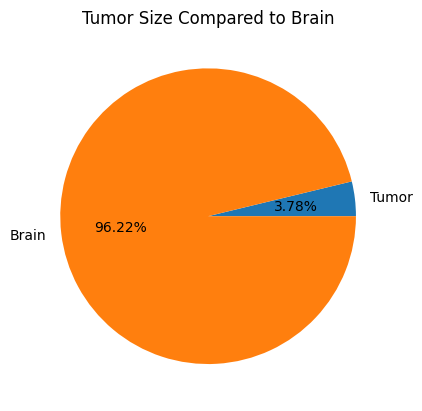

In [19]:
import matplotlib.pyplot as plt


# If it's a proportion (out of 1)
sizes = [pixel_count, 1 - pixel_count]
labels = ["Tumor", "Brain"]

plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.2f%%')
plt.title("Tumor Size Compared to Brain")
plt.show()
